In [1]:
# %%
# https://lightning.ai/docs/pytorch/stable/deploy/production_basic.html
import lightning as pl
from denoising.networks import UNet, REDCNN
from denoising.data import MayoLDGCDataModule # Import the necessary modules
# Define the model
models = {'UNet': UNet.load_from_checkpoint('/home/brandon.nelson/Dev/pediatric-CT-noise-texture-augmentation/denoising/lightning_logs/2025-03-05_19-45_ldgc_chest/train_adult_0_UNet_1/lightning_logs/version_0/checkpoints/epoch=99-step=187600.ckpt'),
          'REDCNN': REDCNN.load_from_checkpoint('/home/brandon.nelson/Dev/pediatric-CT-noise-texture-augmentation/denoising/lightning_logs/2025-03-05_19-45_ldgc_chest/train_adult_0_REDCNN_1/lightning_logs/version_0/checkpoints/epoch=99-step=187600.ckpt')}

# Define the data module
data_module = MayoLDGCDataModule(data_dir='/projects01/didsr-aiml/common_data/Mayo_CT_LDGC', region='chest')
data_module.setup('predict')
# Train the model
trainer = pl.Trainer() # Use GPU
dataloader = data_module.predict_dataloader()
outputs = {name: trainer.predict(model, dataloader) for name, model in models.items()}

/home/brandon.nelson/Dev/pediatric-CT-noise-texture-augmentation/.noise_augmentation/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/brandon.nelson/Dev/pediatric-CT-noise-texture- ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/brandon.nelson/Dev/pediatric-CT-noise-texture-augmentation/.noise_augmentation/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

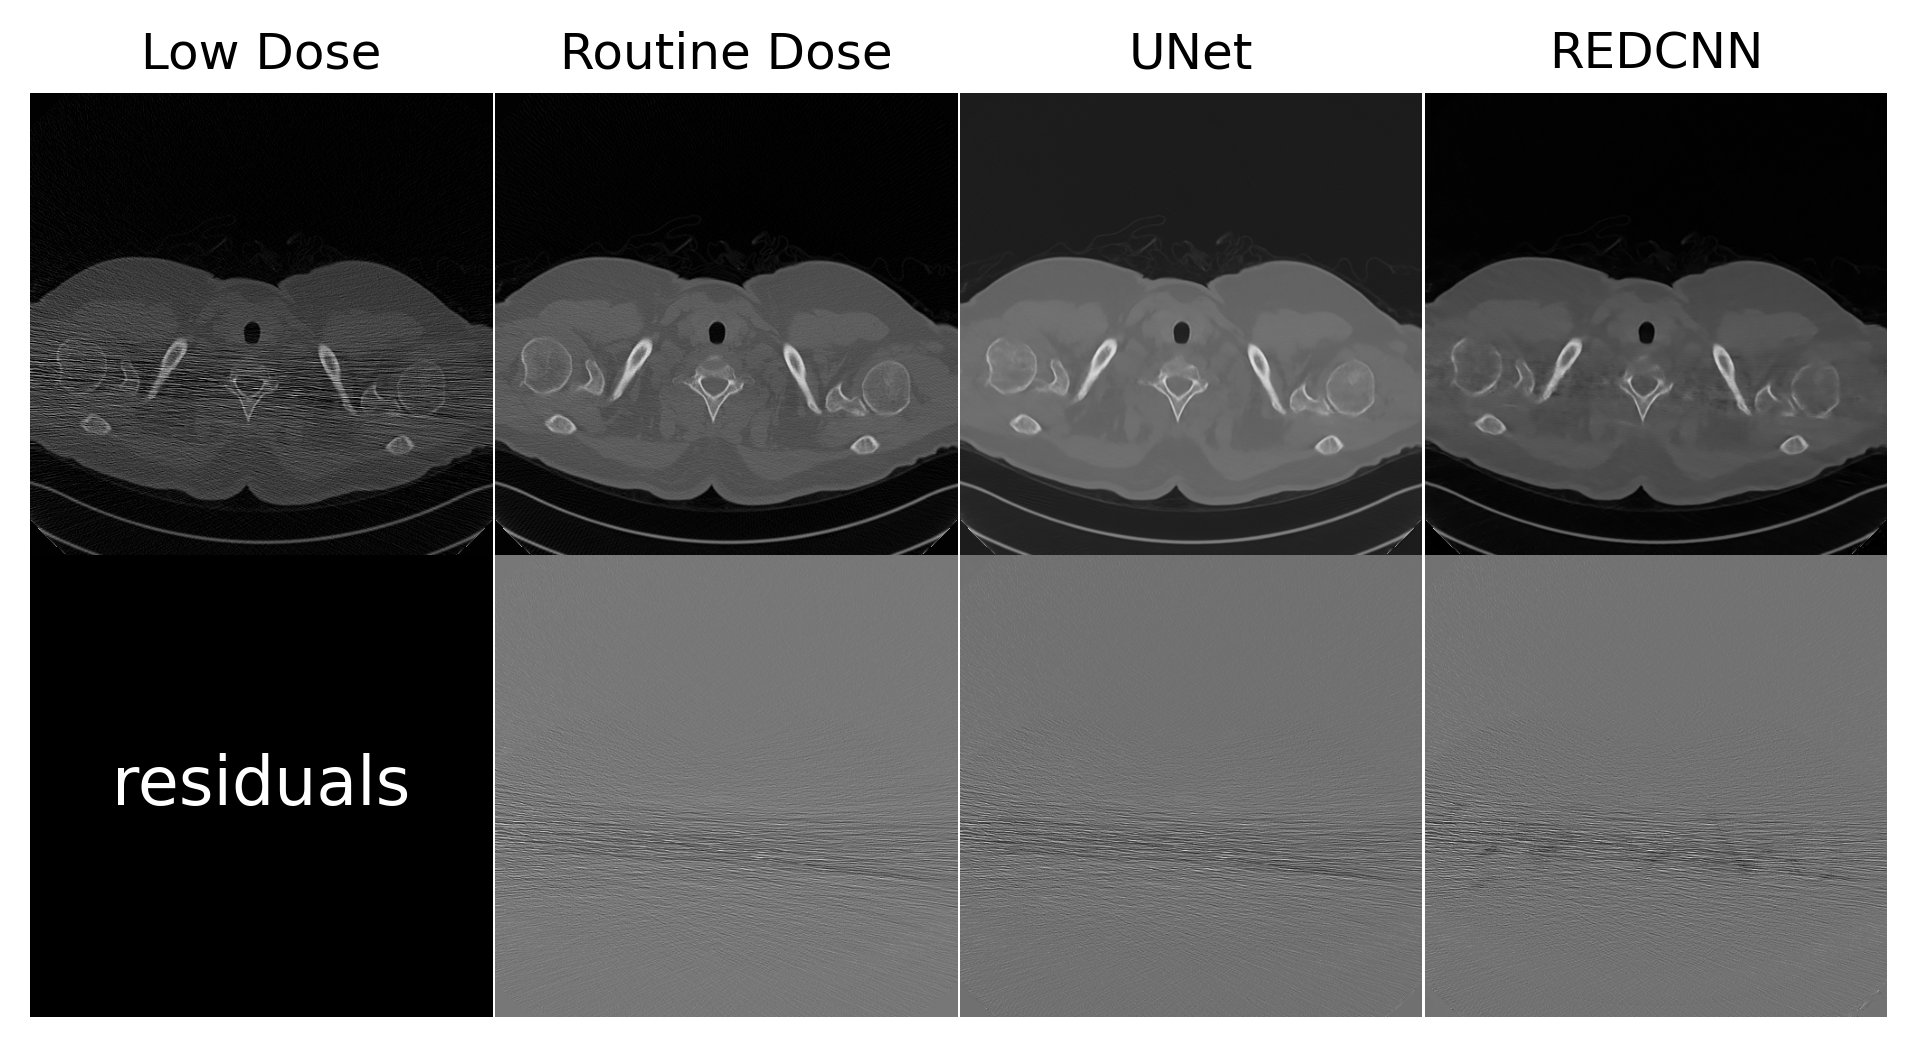

In [2]:
import matplotlib.pyplot as plt
n_examples = 1
cols = 2 + len(models)
f, axs = plt.subplots(2*n_examples, cols, gridspec_kw=dict(wspace=0, hspace=0), figsize=(2*cols, n_examples*4), dpi=300)

row = 0
for _ in range(n_examples):
    for x, y in dataloader:
        break

    axs[row, 0].imshow(x[0].squeeze(), cmap='gray')
    axs[row, 0].set_title('Low Dose')
    axs[row, 0].set_axis_off()
    axs[row, 1].imshow(y[0].squeeze(), cmap='gray')
    axs[row, 1].set_title('Routine Dose')
    axs[row, 1].set_axis_off()
    axs[row + 1, 0].imshow(x[0].squeeze() - x[0].squeeze(), cmap='gray')
    axs[row + 1, 0].annotate('residuals' , xy=(0.5, 0.5), xycoords='axes fraction',
                    va='center', ha='center', color='white', fontsize=16)
    axs[row + 1, 0].set_axis_off()
    axs[row + 1, 1].imshow(x[0].squeeze() - y[0].squeeze(), cmap='gray')
    axs[row + 1, 1].set_axis_off()

    for i, name in enumerate(outputs):
        axs[row, 2 + i].imshow(outputs[name][0][0].squeeze(), cmap='gray')
        axs[row, 2 + i].set_title(name)
        axs[row, 2 + i].set_axis_off()
        axs[row + 1, 2 + i].imshow(x[0].squeeze() - outputs[name][0][0].squeeze(), cmap='gray')
        axs[row + 1, 2 + i].set_axis_off()
    row += 2
plt.show()